# Isolation Forest for Outlier Detection - EAC Dataset

This notebook implements Isolation Forest algorithm to identify outliers and anomalies in the EAC (Encuesta Anual de Comercio) dataset from DANE. Isolation Forest is particularly effective for detecting anomalies in high-dimensional data by isolating observations through random partitioning.

## Objectives
1. Load and preprocess the EAC dataset
2. Apply Isolation Forest for anomaly detection
3. Analyze and visualize detected outliers
4. Compare outliers with business rule violations
5. Generate insights for data quality improvement

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## Data Loading and Initial Exploration

In [2]:
# Load the dataset
df = pd.read_csv("../dataFrames/data.csv")

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")
df.head()

Dataset shape: (9984, 64)
Columns: ['V1', 'CORRELA_16', 'CORRE_9', 'IDOJ1', 'IDAIO', 'CIMREP', 'BRUTA', 'CONSUI', 'GAS', 'EMPAQUE', 'HONORA', 'COMISION', 'ARRIENDO', 'SEGURO', 'ASEO', 'ENERGIA', 'COMUNICA', 'PUBLICO', 'FLETES', 'PUBLICI', 'ADECUA', 'REGALA', 'OUTSOURCING', 'OTROS', 'SUELDOS', 'PRESTAC', 'VENTA', 'AGREGA', 'PERREMUN', 'SOCIOS', 'PERSONOM', 'DIRECTO', 'AGENCIA', 'APRENDIZ', 'TOTPERSO', 'PROMUJ', 'PROHOM', 'PERMUJ', 'PERHOM', 'DIRMUJ', 'DIRHOM', 'AGEMUJ', 'AGEHOM', 'APRENMUJ', 'APRENHOM', 'TOTMUJ', 'TOTHOM', 'SUEPLAN', 'PREPLAN', 'REMPLAN', 'COTIZA', 'GASAGEN', 'REMTEMP', 'TOTREM', 'INVINI', 'INVFIN', 'ROTACION', 'INVPRO', 'CTO', 'CTOINS', 'VENTASNOP', 'GASTOS', 'GASTOSNOP', 'GASTOPNOP']

First few rows:


,V1,CORRELA_16,CORRE_9,IDOJ1,IDAIO,CIMREP,BRUTA,CONSUI,GAS,EMPAQUE,...,INVINI,INVFIN,ROTACION,INVPRO,CTO,CTOINS,VENTASNOP,GASTOS,GASTOSNOP,GASTOPNOP
0,987664,4711-472,471-472,11.0,1986.0,0,603028,"112214,5",0,0,...,2409090,2499584,4837343,2454337,4837343,4837343,0,4980000,1110,5145586
1,987666,462,462-463,14.0,1996.0,0,1083695,77336,780,2970,...,3193,476400,4820346,"239796,5",4820346,4820346,0,4928292,1255,5288743
2,987667,4771-4751,476 - 477,4.0,1991.0,0,190661,26863,0,0,...,431759,422759,515488,427259,515488,515488,0,548094,16772,701070
3,987668,466,466-469,14.0,1986.0,0,2459238,"1262835,5",0,0,...,1963161,2694017,13114471,2328589,13114471,13114471,0,14487926,62938,14895893
4,987669,473,473,5.0,2004.0,0,1688361,"218895,5",0,0,...,141377,172460,7766200,"156918,5",7766200,7766200,0,8044113,57255,8847340


In [3]:
# Data preprocessing function to handle decimal commas
def clean_numeric_data(df):
    """Clean and convert numeric columns with comma decimal separators"""
    df_clean = df.copy()
    
    # Identify numeric columns (exclude ID and categorical columns)
    categorical_cols = ['V1', 'CORRELA_16', 'CORRE_9', 'IDOJ1']
    numeric_cols = [col for col in df.columns if col not in categorical_cols]
    
    for col in numeric_cols:
        if df_clean[col].dtype == 'object':
            # Handle comma as decimal separator and dots as thousand separators
            df_clean[col] = df_clean[col].astype(str).str.replace('.', '', regex=False)
            df_clean[col] = df_clean[col].str.replace(',', '.', regex=False)
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    return df_clean, numeric_cols

# Clean the data
df_clean, numeric_columns = clean_numeric_data(df)

print(f"Numeric columns for analysis: {len(numeric_columns)}")
print(f"Missing values per column:")
print(df_clean[numeric_columns].isnull().sum().sort_values(ascending=False).head(10))

Numeric columns for analysis: 60
Missing values per column:
ROTACION    12
INVFIN       4
IDAIO        3
TOTMUJ       2
TOTHOM       2
GASTOS       1
CTO          1
EMPAQUE      0
GAS          0
CIMREP       0
dtype: int64


## Feature Selection and Preparation for Isolation Forest

In [4]:
# Select key business variables for outlier detection
business_variables = [
    # Production and Sales
    'VENTA', 'BRUTA', 'CONSUI', 'AGREGA', 'CTO', 'CTOINS',
    # Operational Expenses
    'GASTOS', 'GAS', 'EMPAQUE', 'HONORA', 'COMISION', 'ARRIENDO', 
    'SEGURO', 'ENERGIA', 'FLETES', 'PUBLICI', 'OTROS',
    # Personnel and Remuneration
    'TOTPERSO', 'PERREMUN', 'SUELDOS', 'PRESTAC', 'TOTREM',
    # Inventories
    'INVINI', 'INVFIN', 'INVPRO', 'ROTACION'
]

# Filter to variables that exist in the dataset
available_vars = [var for var in business_variables if var in numeric_columns]
print(f"Available business variables: {len(available_vars)}")
print(f"Variables: {available_vars}")

# Create analysis dataset
df_analysis = df_clean[available_vars].copy()

# Handle missing values - remove rows with too many missing values
missing_threshold = 0.3  # Allow up to 30% missing values per row
df_analysis = df_analysis.dropna(thresh=int(len(available_vars) * (1 - missing_threshold)))

# Fill remaining missing values with median
df_analysis = df_analysis.fillna(df_analysis.median())

print(f"\nAnalysis dataset shape: {df_analysis.shape}")
print(f"Remaining missing values: {df_analysis.isnull().sum().sum()}")

Available business variables: 26
Variables: ['VENTA', 'BRUTA', 'CONSUI', 'AGREGA', 'CTO', 'CTOINS', 'GASTOS', 'GAS', 'EMPAQUE', 'HONORA', 'COMISION', 'ARRIENDO', 'SEGURO', 'ENERGIA', 'FLETES', 'PUBLICI', 'OTROS', 'TOTPERSO', 'PERREMUN', 'SUELDOS', 'PRESTAC', 'TOTREM', 'INVINI', 'INVFIN', 'INVPRO', 'ROTACION']

Analysis dataset shape: (9984, 26)
Remaining missing values: 0


In [5]:
# Data scaling and transformation
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_analysis), 
    columns=df_analysis.columns,
    index=df_analysis.index
)

print("Data scaling completed")
print(f"Scaled data shape: {df_scaled.shape}")
print(f"Scaled data summary:")
print(df_scaled.describe())

Data scaling completed
Scaled data shape: (9984, 26)
Scaled data summary:
              VENTA         BRUTA        CONSUI        AGREGA           CTO  \
count  9.984000e+03  9.984000e+03  9.984000e+03  9.984000e+03  9.984000e+03   
mean   1.138690e-17 -7.828496e-18  1.138690e-17 -7.116814e-19  1.352195e-17   
std    1.000050e+00  1.000050e+00  1.000050e+00  1.000050e+00  1.000050e+00   
min   -1.897448e-01 -2.528725e-01 -1.726365e-01 -1.258888e+00 -1.803504e-01   
25%   -1.740454e-01 -1.940242e-01 -1.615039e-01 -2.071337e-01 -1.672019e-01   
50%   -1.500630e-01 -1.679946e-01 -1.444419e-01 -1.773937e-01 -1.449253e-01   
75%   -8.865028e-02 -8.882457e-02 -9.456368e-02 -8.479100e-02 -8.863530e-02   
max    2.950161e+01  2.536603e+01  3.130246e+01  2.380695e+01  2.978633e+01   

             CTOINS        GASTOS           GAS       EMPAQUE        HONORA  \
count  9.984000e+03  9.984000e+03  9.984000e+03  9.984000e+03  9.984000e+03   
mean  -1.921540e-17  1.636867e-17  1.423363e-18  8.54017

## Isolation Forest Implementation

In [6]:
# Initialize and fit Isolation Forest
# contamination parameter: expected proportion of outliers in the dataset
contamination_rate = 0.05  # Assume 5% of data are outliers

isolation_forest = IsolationForest(
    contamination=contamination_rate,
    random_state=42,
    n_estimators=100,
    max_samples='auto',
    n_jobs=-1
)

# Fit the model and predict outliers
outlier_labels = isolation_forest.fit_predict(df_scaled)
outlier_scores = isolation_forest.score_samples(df_scaled)

# Add results to original dataframe
df_results = df_analysis.copy()
df_results['outlier_label'] = outlier_labels  # -1 for outliers, 1 for normal
df_results['outlier_score'] = outlier_scores  # Lower scores indicate outliers
df_results['is_outlier'] = df_results['outlier_label'] == -1

# Summary of results
n_outliers = (outlier_labels == -1).sum()
n_normal = (outlier_labels == 1).sum()

print(f"Isolation Forest Results:")
print(f"Total samples: {len(df_results)}")
print(f"Normal points: {n_normal} ({n_normal/len(df_results)*100:.1f}%)")
print(f"Outliers detected: {n_outliers} ({n_outliers/len(df_results)*100:.1f}%)")
print(f"Outlier score range: {outlier_scores.min():.3f} to {outlier_scores.max():.3f}")

Isolation Forest Results:
Total samples: 9984
Normal points: 9484 (95.0%)
Outliers detected: 500 (5.0%)
Outlier score range: -0.878 to -0.313


## Outlier Analysis and Visualization

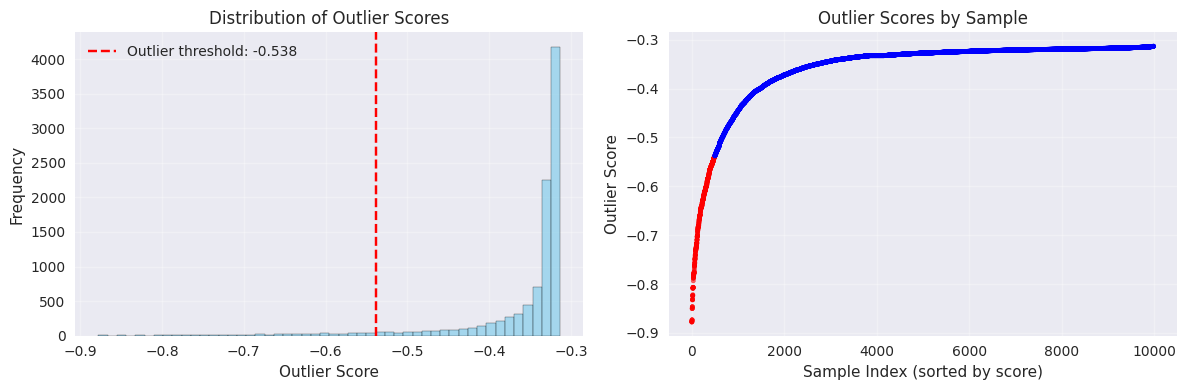

In [7]:
# Outlier score distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(outlier_scores, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(outlier_scores[outlier_labels == -1].max(), color='red', linestyle='--', 
            label=f'Outlier threshold: {outlier_scores[outlier_labels == -1].max():.3f}')
plt.xlabel('Outlier Score')
plt.ylabel('Frequency')
plt.title('Distribution of Outlier Scores')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(range(len(outlier_scores)), np.sort(outlier_scores), 
           c=['red' if x == -1 else 'blue' for x in outlier_labels[np.argsort(outlier_scores)]], 
           alpha=0.6, s=10)
plt.xlabel('Sample Index (sorted by score)')
plt.ylabel('Outlier Score')
plt.title('Outlier Scores by Sample')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

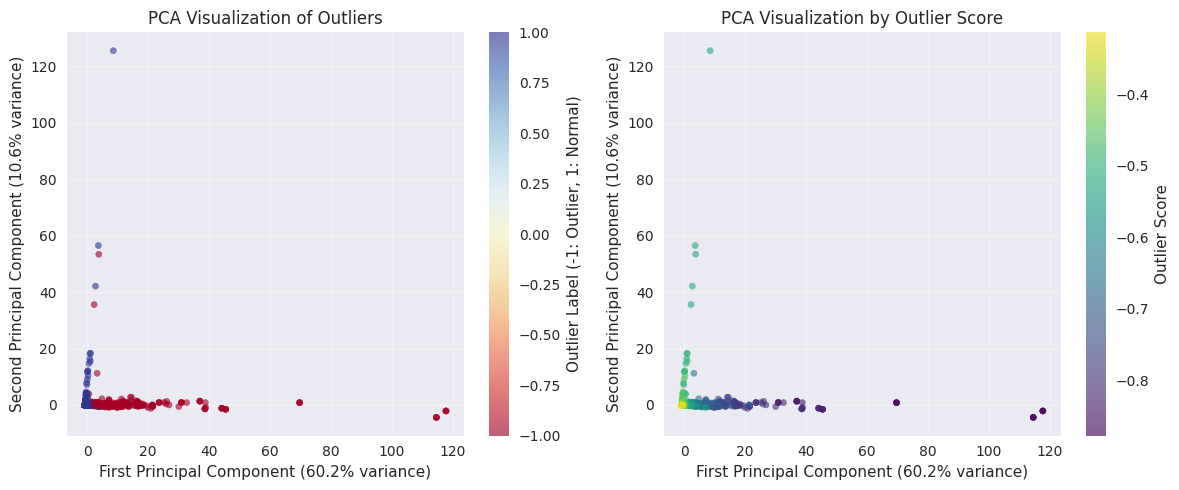

PCA explained variance ratio: [0.60226386 0.1059766 ]
Total variance explained by first 2 components: 70.8%


In [8]:
# PCA visualization of outliers
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], 
                     c=outlier_labels, cmap='RdYlBu', alpha=0.6, s=20)
plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA Visualization of Outliers')
plt.colorbar(scatter, label='Outlier Label (-1: Outlier, 1: Normal)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], 
                     c=outlier_scores, cmap='viridis', alpha=0.6, s=20)
plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA Visualization by Outlier Score')
plt.colorbar(scatter, label='Outlier Score')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained by first 2 components: {pca.explained_variance_ratio_.sum():.1%}")

In [9]:
# Analyze characteristics of outliers vs normal points
def analyze_outlier_characteristics(df_results, variables):
    """Compare outliers vs normal points across different variables"""
    outliers = df_results[df_results['is_outlier']]
    normal = df_results[~df_results['is_outlier']]
    
    comparison = pd.DataFrame({
        'Variable': variables,
        'Normal_Mean': [normal[var].mean() for var in variables],
        'Normal_Median': [normal[var].median() for var in variables],
        'Outlier_Mean': [outliers[var].mean() for var in variables],
        'Outlier_Median': [outliers[var].median() for var in variables],
    })
    
    comparison['Mean_Ratio'] = comparison['Outlier_Mean'] / comparison['Normal_Mean']
    comparison['Median_Ratio'] = comparison['Outlier_Median'] / comparison['Normal_Median']
    
    return comparison

# Analyze key variables
key_vars = ['VENTA', 'BRUTA', 'GASTOS', 'TOTPERSO', 'TOTREM', 'INVPRO']
available_key_vars = [var for var in key_vars if var in df_results.columns]

comparison_df = analyze_outlier_characteristics(df_results, available_key_vars)
print("Outlier vs Normal Comparison:")
print(comparison_df.round(2))

Outlier vs Normal Comparison:
   Variable  Normal_Mean  Normal_Median  Outlier_Mean  Outlier_Median  \
0     VENTA  20908996.91    10016062.50  6.416660e+08    2.985233e+08   
1     BRUTA   4558523.95     2017888.50  1.261721e+08    6.452772e+07   
2    GASTOS  17846607.52     8309205.00  5.658659e+08    2.581850e+08   
3  TOTPERSO        36.91          21.00  7.008600e+02    3.105000e+02   
4    TOTREM   1203158.21      576533.46  2.760705e+07    1.533791e+07   
5    INVPRO   8494124.50     1204916.75  1.042372e+08    4.388924e+07   

   Mean_Ratio  Median_Ratio  
0       30.69         29.80  
1       27.68         31.98  
2       31.71         31.07  
3       18.99         14.79  
4       22.95         26.60  
5       12.27         36.43  


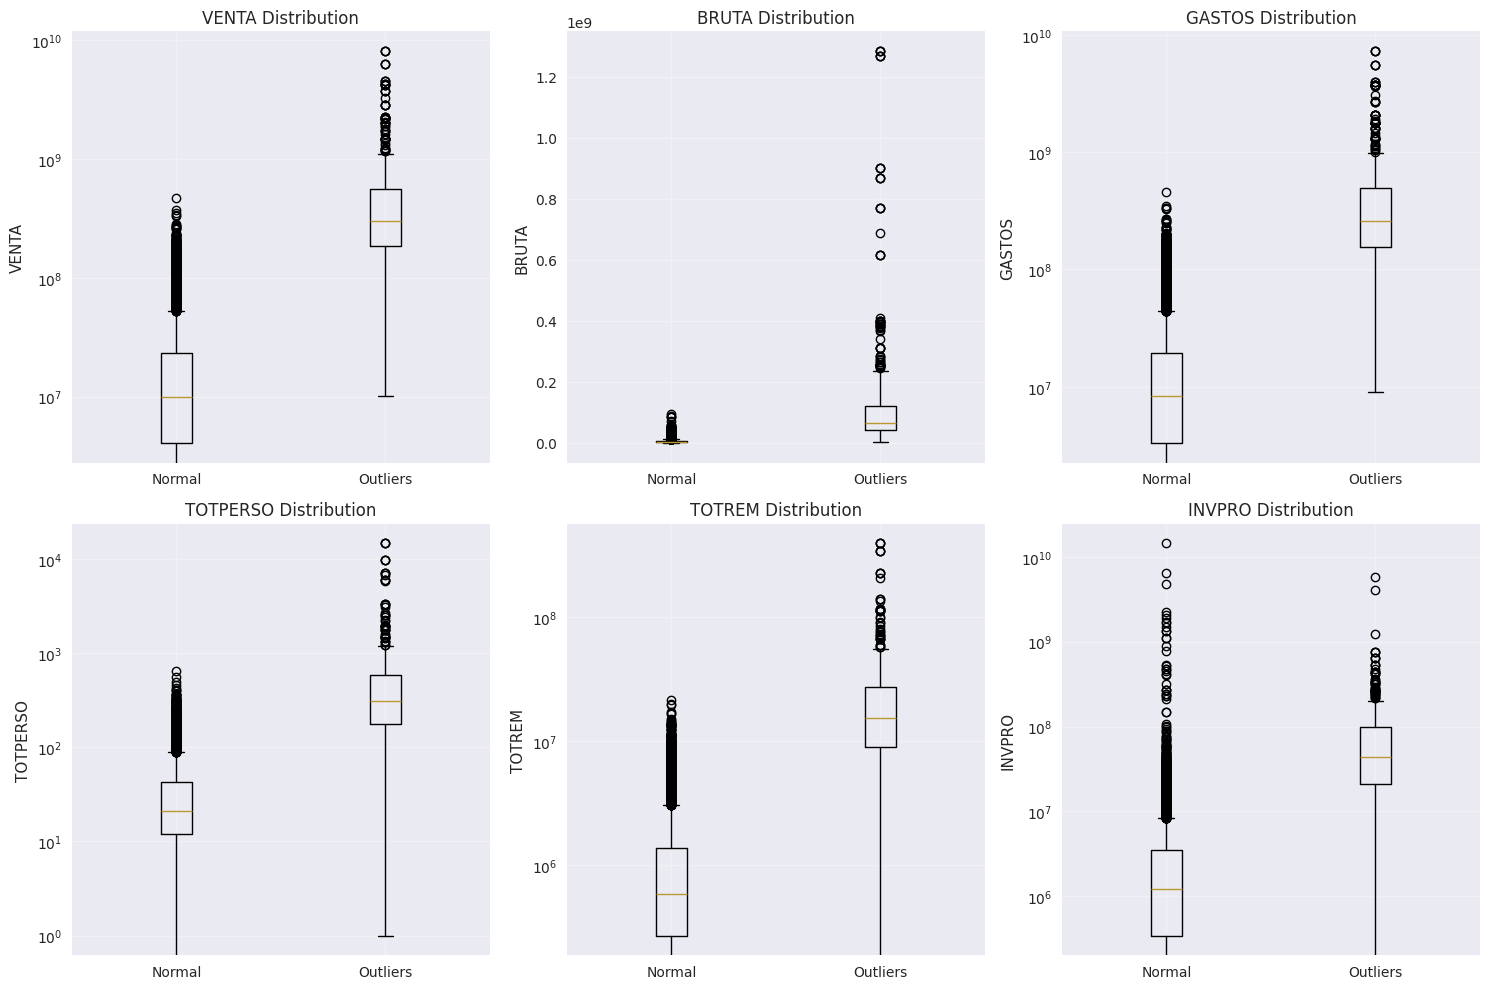

In [10]:
# Box plots comparing outliers vs normal points
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, var in enumerate(available_key_vars):
    if i < len(axes):
        data_to_plot = [
            df_results[~df_results['is_outlier']][var].dropna(),
            df_results[df_results['is_outlier']][var].dropna()
        ]
        
        axes[i].boxplot(data_to_plot, labels=['Normal', 'Outliers'])
        axes[i].set_title(f'{var} Distribution')
        axes[i].set_ylabel(var)
        axes[i].grid(True, alpha=0.3)
        
        # Log scale for better visualization if values are very different
        if df_results[var].max() / df_results[var].min() > 1000:
            axes[i].set_yscale('log')

plt.tight_layout()
plt.show()

## Integration with Business Rule Validation

Comparison with Business Rule Validation:
Business rule violations: 221
Isolation Forest outliers: 500
Overlap: 5 (2.3% of business violations)
Only in business rules: 216
Only in Isolation Forest: 495


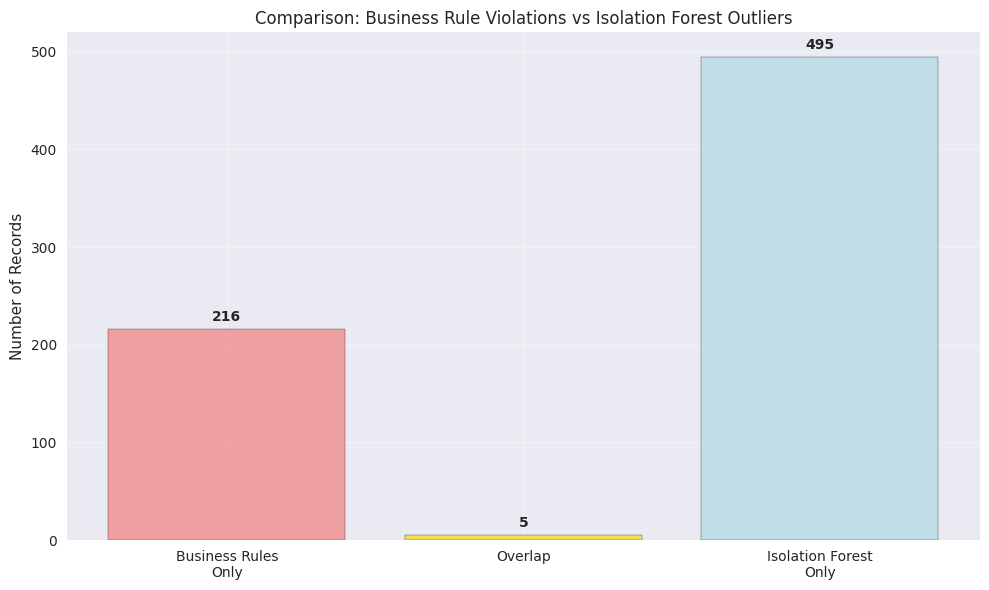

In [11]:
# Load business rule violations for comparison
try:
    invalid_data = pd.read_csv("../dataFrames/invalidData.csv")
    
    # Get indices of business rule violations
    business_rule_violations = set(invalid_data.index) if 'index' not in invalid_data.columns else set(invalid_data['index'])
    
    # Get indices of isolation forest outliers
    isolation_outliers = set(df_results[df_results['is_outlier']].index)
    
    # Calculate overlap
    overlap = business_rule_violations.intersection(isolation_outliers)
    only_business_rules = business_rule_violations - isolation_outliers
    only_isolation_forest = isolation_outliers - business_rule_violations
    
    print("Comparison with Business Rule Validation:")
    print(f"Business rule violations: {len(business_rule_violations)}")
    print(f"Isolation Forest outliers: {len(isolation_outliers)}")
    print(f"Overlap: {len(overlap)} ({len(overlap)/len(business_rule_violations)*100:.1f}% of business violations)")
    print(f"Only in business rules: {len(only_business_rules)}")
    print(f"Only in Isolation Forest: {len(only_isolation_forest)}")
    
    # Create comparison visualization
    plt.figure(figsize=(10, 6))
    
    categories = ['Business Rules\nOnly', 'Overlap', 'Isolation Forest\nOnly']
    values = [len(only_business_rules), len(overlap), len(only_isolation_forest)]
    colors = ['lightcoral', 'gold', 'lightblue']
    
    plt.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')
    plt.title('Comparison: Business Rule Violations vs Isolation Forest Outliers')
    plt.ylabel('Number of Records')
    plt.grid(True, alpha=0.3)
    
    for i, v in enumerate(values):
        plt.text(i, v + max(values)*0.01, str(v), ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
except FileNotFoundError:
    print("Invalid data file not found. Skipping business rule comparison.")
    print("Run the business rule validator first to generate invalidData.csv")

## Detailed Outlier Investigation

In [12]:
# Examine the most extreme outliers
top_outliers = df_results.nsmallest(10, 'outlier_score')

print("Top 10 Most Extreme Outliers:")
print("=" * 50)
for idx, row in top_outliers.iterrows():
    print(f"\nRecord Index: {idx}")
    print(f"Outlier Score: {row['outlier_score']:.4f}")
    print("Key Characteristics:")
    for var in available_key_vars:
        if var in row:
            print(f"  {var}: {row[var]:,.0f}")

# Feature importance analysis
feature_importance = np.abs(df_scaled.loc[df_results['is_outlier']].mean() - 
                           df_scaled.loc[~df_results['is_outlier']].mean())

importance_df = pd.DataFrame({
    'Feature': df_scaled.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print(f"\nFeature Importance for Outlier Detection:")
print("=" * 50)
print(importance_df.head(10).to_string(index=False))

Top 10 Most Extreme Outliers:

Record Index: 4191
Outlier Score: -0.8776
Key Characteristics:
  VENTA: 6,261,900,665
  BRUTA: 1,266,240,563
  GASTOS: 5,561,837,658
  TOTPERSO: 14,526
  TOTREM: 392,634,816
  INVPRO: 753,796,979

Record Index: 5269
Outlier Score: -0.8776
Key Characteristics:
  VENTA: 6,261,900,665
  BRUTA: 1,266,240,563
  GASTOS: 5,561,837,658
  TOTPERSO: 14,526
  TOTREM: 392,634,816
  INVPRO: 753,796,979

Record Index: 8848
Outlier Score: -0.8776
Key Characteristics:
  VENTA: 6,261,900,665
  BRUTA: 1,266,240,563
  GASTOS: 5,561,837,658
  TOTPERSO: 14,526
  TOTREM: 392,634,816
  INVPRO: 753,796,979

Record Index: 5649
Outlier Score: -0.8764
Key Characteristics:
  VENTA: 8,136,452,936
  BRUTA: 1,284,383,431
  GASTOS: 7,315,479,383
  TOTPERSO: 9,734
  TOTREM: 342,282,916
  INVPRO: 527,130,124

Record Index: 5657
Outlier Score: -0.8764
Key Characteristics:
  VENTA: 8,136,452,936
  BRUTA: 1,284,383,431
  GASTOS: 7,315,479,383
  TOTPERSO: 9,734
  TOTREM: 342,282,916
  INVPRO:

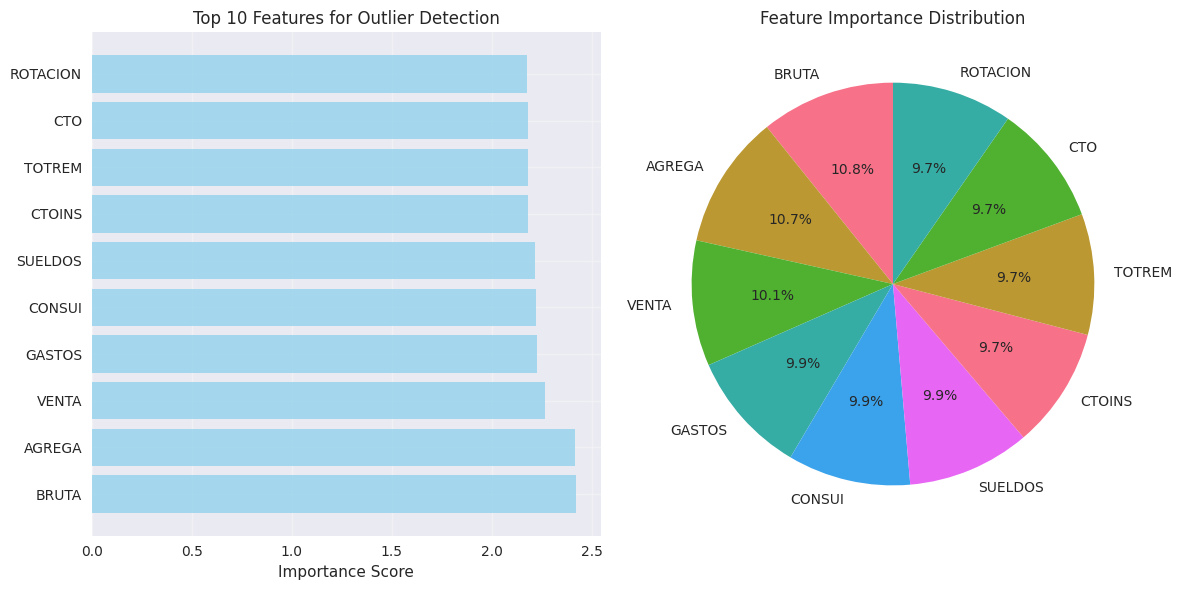

In [13]:
# Feature importance visualization
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
top_features = importance_df.head(10)
plt.barh(range(len(top_features)), top_features['Importance'], color='skyblue', alpha=0.7)
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score')
plt.title('Top 10 Features for Outlier Detection')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.pie(top_features['Importance'], labels=top_features['Feature'], autopct='%1.1f%%', startangle=90)
plt.title('Feature Importance Distribution')

plt.tight_layout()
plt.show()

## Export Results and Summary

In [14]:
# Export outlier results
outlier_results = df_results[df_results['is_outlier']].copy()
outlier_results = outlier_results.sort_values('outlier_score')

# Save to CSV
outlier_results.to_csv("../dataFrames/isolation_forest_outliers.csv", index=True)

print(f"Exported {len(outlier_results)} outliers to isolation_forest_outliers.csv")

# Summary statistics
print("\n" + "="*60)
print("ISOLATION FOREST OUTLIER DETECTION SUMMARY")
print("="*60)
print(f"Dataset: EAC DANE Commercial Survey")
print(f"Total records analyzed: {len(df_results):,}")
print(f"Features used: {len(available_vars)}")
print(f"Contamination rate: {contamination_rate:.1%}")
print(f"\nResults:")
print(f"  • Normal records: {n_normal:,} ({n_normal/len(df_results)*100:.1f}%)")
print(f"  • Outliers detected: {n_outliers:,} ({n_outliers/len(df_results)*100:.1f}%)")
print(f"  • Score range: {outlier_scores.min():.4f} to {outlier_scores.max():.4f}")

print(f"\nTop contributing features:")
for i, (_, row) in enumerate(importance_df.head(5).iterrows()):
    print(f"  {i+1}. {row['Feature']}: {row['Importance']:.3f}")

print(f"\nOutlier characteristics (vs normal):")
for var in available_key_vars[:3]:  # Show top 3 variables
    outlier_mean = outlier_results[var].mean()
    normal_mean = df_results[~df_results['is_outlier']][var].mean()
    ratio = outlier_mean / normal_mean if normal_mean != 0 else float('inf')
    print(f"  • {var}: {ratio:.1f}x {'higher' if ratio > 1 else 'lower'} than normal")

print("="*60)

Exported 500 outliers to isolation_forest_outliers.csv

ISOLATION FOREST OUTLIER DETECTION SUMMARY
Dataset: EAC DANE Commercial Survey
Total records analyzed: 9,984
Features used: 26
Contamination rate: 5.0%

Results:
  • Normal records: 9,484 (95.0%)
  • Outliers detected: 500 (5.0%)
  • Score range: -0.8776 to -0.3130

Top contributing features:
  1. BRUTA: 2.422
  2. AGREGA: 2.415
  3. VENTA: 2.265
  4. GASTOS: 2.227
  5. CONSUI: 2.219

Outlier characteristics (vs normal):
  • VENTA: 30.7x higher than normal
  • BRUTA: 27.7x higher than normal
  • GASTOS: 31.7x higher than normal
